# Mutant Moneyball Data Cleaning and Visualizations

In this notebook, I will clean and transform the `mutant_moneyball.csv` dataset using the tidy data principles and create visualizations to reflect the newly cleaned data.

## What is tidy data and why is it important?

According to Hadley Wickham's article "Tidy Data" from the Journal of Statistical Software, tidying data is the process of structuring datasets to facilitate analysis. In tidy data,

1. Each variable forms a column  
2. Each observation forms a row
3. Each type of observational unit forms a table

Tidy data is more consistent, which makes it easier to read and use for analysis and visualizations. Trying to do the same on messy data would not only be very painstaking but also make a data scientist more prone to mistakes and false conclusions. With every variable in a unique column and each observation in a unique row, it makes it much simpler to filter and look at specific cases, find a specific observation (since it isn't spread across rows and columns), generate summary statistics and visualizations, and more.

To start on `mutant_moneyball.csv`, I get a general look at the dataset and look for potential issues to fix.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/ldeend/Dee-Data-Science-Portfolio/refs/heads/main/TidyData-Project/datasets/mutant_moneyball.csv")
df.head()

,Member,TotalValue60s_heritage,TotalValue70s_heritage,TotalValue80s_heritage,TotalValue90s_heritage,TotalValue60s_ebay,TotalValue70s_ebay,TotalValue80s_ebay,TotalValue90s_ebay,TotalValue60s_wiz,TotalValue70s_wiz,TotalValue80s_wiz,TotalValue90s_wiz,TotalValue60s_oStreet,TotalValue70s_oStreet,TotalValue80s_oStreet,TotalValue90s_oStreet
0,warrenWorthington,929056.0,154585.0,23957.0,960.0,23335.0,3362.0,583.0,97.0,"$7,913.00","$1,105.00",$226.00,$65.75,"$68,160.00","$7,360.00",$975.00,$123.00
1,hankMcCoy,929776.0,20705.0,6631.0,881.0,23377.0,1224.0,289.0,82.0,"$7,953.00",$851.00,$89.00,$38.50,"$68,390.00","$5,260.00",$431.00,$81.00
2,scottSummers,933616.0,188635.0,29240.0,739.0,23420.0,5431.0,1031.0,82.0,"$7,993.00","$1,979.00",$438.00,$39.25,"$68,590.00","$11,675.00","$1,427.00",$74.00
3,bobbyDrake,929776.0,154585.0,1514.0,874.0,23377.0,3362.0,70.0,93.0,"$7,953.00","$1,105.00",$48.00,$62.00,"$68,390.00","$7,360.00",$137.00,$108.00
4,jeanGrey,933616.0,179899.0,16868.0,1708.0,23420.0,4903.0,665.0,170.0,"$7,993.00","$1,679.00",$165.00,$108.00,"$68,590.00","$10,265.00",$822.00,$189.00


In [4]:
print("\nDescription:")
print(df.describe())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nShape of dataset:", df.shape)


Description:
       TotalValue60s_heritage  TotalValue70s_heritage  TotalValue80s_heritage  \
count               10.000000               16.000000               23.000000   
mean            620830.900000           143405.687500            19819.521739   
std             408395.112113            53348.542806            19213.492572   
min              34519.000000             3479.000000              143.000000   
25%             202942.750000           144177.500000             6087.500000   
50%             874296.500000           160441.000000            10730.000000   
75%             929776.000000           171050.000000            34947.500000   
max             933616.000000           188635.000000            54205.000000   

       TotalValue90s_heritage  TotalValue60s_ebay  TotalValue70s_ebay  \
count               22.000000           10.000000           16.000000   
mean               943.727273        15697.700000         3445.750000   
std                591.515904        

## Is this dataset clean already? If not, what's wrong?

This dataset is clearly messy data. The column names contain multiple variables combined, and each column has multiple pieces of information: decade and source. This violates the tidy data principle 1, that each variable has its own column. Take, for example, the column `TotalValue60s_ebay`. A cell in this column will tell us the value of a comic, the decade it is from, and the source of that value. 

Another issue this dataset has is that every row has information about the value of a character across decades and from different sources, but the tidy data principle 2 says each observation should have its own row. With this dataset, one observation is the total value of an X-Men team member's total number of issues as reflected by a source's highest sale. 

Combining these two principles, the clean dataset will have in each row the X-Men member, the decade the comic is from, the total value, and the source the value is from. This means that the tidy dataset will have these separate, unique columns: Member, Decade, Source, Value.

There are also some missing values, but they shouldn't provide any problems as long as they are empty and not filled with text such as "No entry." This is not the case since they come up as NaN. The last issue is the formatting of the value. For example, here are two different cells: `1730` and `$931.00`. This will clearly be an issue for summary statistics and visualizations, so I will homogenize this formatting.

## Tidying Step 1: Melting 

To address the second tidy principle, I will use `melt()` to give each observation its own row.

Melting takes the columns and stacks them into the rows so that the dataset becomes longer with fewer columns and many more rows. The column names, again in the format `TotalValue60s_ebay`, will become cell entries under the column called `Info` (this is just a placeholder), and their old cell entries (which were the total value) will become a new column called `Value`. 


In [7]:
# Copying the dataset to transform
mmb = df.copy()
mmb.head()

mmb_melt = mmb.melt(
    id_vars = "Member",
    var_name = "Info",
    value_name = "Value")

print("\nShape of melted dataset")
print(mmb_melt.shape)

mmb_melt.head(10)


Shape of melted dataset
(416, 3)


,Member,Info,Value
0,warrenWorthington,TotalValue60s_heritage,929056.0
1,hankMcCoy,TotalValue60s_heritage,929776.0
2,scottSummers,TotalValue60s_heritage,933616.0
3,bobbyDrake,TotalValue60s_heritage,929776.0
4,jeanGrey,TotalValue60s_heritage,933616.0
5,alexSummers,TotalValue60s_heritage,34519.0
6,lornaDane,TotalValue60s_heritage,76279.0
7,ororoMunroe,TotalValue60s_heritage,NaN
8,kurtWagner,TotalValue60s_heritage,NaN
9,loganHowlett,TotalValue60s_heritage,NaN


The melt worked, and now each observation has its own row. However, there is still the issue that the `Info` column contains multiple variables.

## Tidying Step 2: Splitting the combined column into separate variable columns

The `Info` column still has multiple bits of information in it when we want it to just have one. It has information on the decade the comic was from and whether the source was eBay, oStreet, Heritage, or Wiz. Therefore, we want to split these up.

For example, `TotalValue60s_ebay` turns into `ToalValue60s` `ebay`. 

First I will split the "_" and create two new columns.

In [9]:
mmb_melt[["TotalValuedecade", "Source"]] = mmb_melt["Info"].str.split("_", n = 1, expand = True)
mmb_melt.head(10)

,Member,Info,Value,TotalValuedecade,Source
0,warrenWorthington,TotalValue60s_heritage,929056.0,TotalValue60s,heritage
1,hankMcCoy,TotalValue60s_heritage,929776.0,TotalValue60s,heritage
2,scottSummers,TotalValue60s_heritage,933616.0,TotalValue60s,heritage
3,bobbyDrake,TotalValue60s_heritage,929776.0,TotalValue60s,heritage
4,jeanGrey,TotalValue60s_heritage,933616.0,TotalValue60s,heritage
5,alexSummers,TotalValue60s_heritage,34519.0,TotalValue60s,heritage
6,lornaDane,TotalValue60s_heritage,76279.0,TotalValue60s,heritage
7,ororoMunroe,TotalValue60s_heritage,NaN,TotalValue60s,heritage
8,kurtWagner,TotalValue60s_heritage,NaN,TotalValue60s,heritage
9,loganHowlett,TotalValue60s_heritage,NaN,TotalValue60s,heritage


Then, I will remove the "TotalValue" from `TotalValue60s` to go to `60s`, for example, since it no longer makes sense

In [11]:
mmb_melt["Decade"] = mmb_melt["TotalValuedecade"].str.replace("TotalValue", "", regex = False)
mmb_melt.head(10)

,Member,Info,Value,TotalValuedecade,Source,Decade
0,warrenWorthington,TotalValue60s_heritage,929056.0,TotalValue60s,heritage,60s
1,hankMcCoy,TotalValue60s_heritage,929776.0,TotalValue60s,heritage,60s
2,scottSummers,TotalValue60s_heritage,933616.0,TotalValue60s,heritage,60s
3,bobbyDrake,TotalValue60s_heritage,929776.0,TotalValue60s,heritage,60s
4,jeanGrey,TotalValue60s_heritage,933616.0,TotalValue60s,heritage,60s
5,alexSummers,TotalValue60s_heritage,34519.0,TotalValue60s,heritage,60s
6,lornaDane,TotalValue60s_heritage,76279.0,TotalValue60s,heritage,60s
7,ororoMunroe,TotalValue60s_heritage,NaN,TotalValue60s,heritage,60s
8,kurtWagner,TotalValue60s_heritage,NaN,TotalValue60s,heritage,60s
9,loganHowlett,TotalValue60s_heritage,NaN,TotalValue60s,heritage,60s


## Tidying Step 3: Homogenize Value Units

Going back to another issue I saw earlier, some of the values have different formatting with dollar signs and commas instead of the value by itself. We can see that some of the column data types are object instead of float, and we want them all to be numeric as float so that the values can be added, averaged, or have any other analysis/visualization performed on them.

Currently, the `Value` column has some cells with unitless values and some with dollar signs and commas. Examples: `700` vs `$1,800.00`. I will remove those symbols and convert the values to numeric format (float64 instead of object) so the data can be summarized and plotted correctly.

In [13]:
print("\nOriginal 'Value' data type:")
print(mmb_melt['Value'].dtypes)


mmb_melt["Value"] = (
    mmb_melt["Value"]
    .astype(str)
    .str.replace("$", "", regex = False)
    .str.replace(",", "", regex =False)
    .str.strip())


mmb_melt["Value"] = pd.to_numeric(mmb_melt["Value"], errors = "coerce")

print("\nNew 'Value' data type:")
print(mmb_melt['Value'].dtypes)
mmb_melt.head(10)


Original 'Value' data type:
object

New 'Value' data type:
float64


,Member,Info,Value,TotalValuedecade,Source,Decade
0,warrenWorthington,TotalValue60s_heritage,929056.0,TotalValue60s,heritage,60s
1,hankMcCoy,TotalValue60s_heritage,929776.0,TotalValue60s,heritage,60s
2,scottSummers,TotalValue60s_heritage,933616.0,TotalValue60s,heritage,60s
3,bobbyDrake,TotalValue60s_heritage,929776.0,TotalValue60s,heritage,60s
4,jeanGrey,TotalValue60s_heritage,933616.0,TotalValue60s,heritage,60s
5,alexSummers,TotalValue60s_heritage,34519.0,TotalValue60s,heritage,60s
6,lornaDane,TotalValue60s_heritage,76279.0,TotalValue60s,heritage,60s
7,ororoMunroe,TotalValue60s_heritage,NaN,TotalValue60s,heritage,60s
8,kurtWagner,TotalValue60s_heritage,NaN,TotalValue60s,heritage,60s
9,loganHowlett,TotalValue60s_heritage,NaN,TotalValue60s,heritage,60s


## Final Tidy Dataset

Finally, I can remove the rows that I do not need anymore and get down to just the columns that are needed. Those columns are: 

- `Member`
- `Decade`
- `Source`
- `Value`

Each variable has its own column, each row has its own observation, and there is only one type of observation unit: Total Value.

In [15]:
mmb_tidy = mmb_melt[["Member", "Decade", "Source", "Value"]].copy()
mmb_tidy.head(10)

,Member,Decade,Source,Value
0,warrenWorthington,60s,heritage,929056.0
1,hankMcCoy,60s,heritage,929776.0
2,scottSummers,60s,heritage,933616.0
3,bobbyDrake,60s,heritage,929776.0
4,jeanGrey,60s,heritage,933616.0
5,alexSummers,60s,heritage,34519.0
6,lornaDane,60s,heritage,76279.0
7,ororoMunroe,60s,heritage,NaN
8,kurtWagner,60s,heritage,NaN
9,loganHowlett,60s,heritage,NaN


Since `Member` is the first variable and because it makes sense to, I will sort the values by Member and then by decade. Source will be ordered as: `ebay`, `heritage`, `oStreet`, `wiz`. 

In [17]:
mmb_tidy = mmb_tidy.sort_values(["Member", "Decade", "Source"]).reset_index(drop = True)
mmb_tidy.head(10)

,Member,Decade,Source,Value
0,alexSummers,60s,ebay,745.0
1,alexSummers,60s,heritage,34519.0
2,alexSummers,60s,oStreet,1850.0
3,alexSummers,60s,wiz,342.0
4,alexSummers,70s,ebay,2703.0
5,alexSummers,70s,heritage,144946.0
6,alexSummers,70s,oStreet,3865.0
7,alexSummers,70s,wiz,597.0
8,alexSummers,80s,ebay,581.0
9,alexSummers,80s,heritage,9352.0


In [18]:
print("\nDescription:")
print(mmb_tidy.describe())

print("\nInfo:")
print(mmb_tidy.info())

print("\nMissing values:")
print(mmb_tidy.isna().sum())

mmb_tidy.to_csv("mutant_moneyball_clean.csv", index = False)


Description:
               Value
count     284.000000
mean    34740.815141
std    138593.312028
min         1.000000
25%       139.250000
50%       878.000000
75%      6609.250000
max    933616.000000

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Member  416 non-null    object 
 1   Decade  416 non-null    object 
 2   Source  416 non-null    object 
 3   Value   284 non-null    float64
dtypes: float64(1), object(3)
memory usage: 13.1+ KB
None

Missing values:
Member      0
Decade      0
Source      0
Value     132
dtype: int64


## Final look at the dataset

A final look at the dataset shows that it fulfills all three of the tidy data principles. Each variable has its own column, each observation has its own row, and the only observational unit in this dataset is the total value.

Now, the dataset is ready to analyze, summarize, and visualize.

## Pivot-Table 1: Average total value table by decade and source


In [21]:
avg_decade_source = pd.pivot_table(
    mmb_tidy,
    index = "Source",
    columns = "Decade",
    values = "Value",
    aggfunc = "mean")


avg_decade_source

Decade,60s,70s,80s,90s
Source,,,,
ebay,15697.7,3445.7500,650.869565,98.045455
heritage,620830.9,143405.6875,19819.521739,943.727273
oStreet,45678.5,6291.5625,873.434783,103.818182
wiz,5204.8,1036.3750,339.000000,67.931818


## Pivot-Table 2: Top 10 X-Men Members ranked by total value

In [23]:
members_ranked = mmb_tidy.groupby("Member", as_index = False)["Value"].sum()
members_ranked = members_ranked.sort_values("Value", ascending = False)


members_ranked.head(10)

,Member,Value
22,scottSummers,1274409.25
8,jeanGrey,1251060.00
25,warrenWorthington,1221862.75
4,bobbyDrake,1198814.00
5,charlesXavier,1139010.00
7,hankMcCoy,1066058.50
6,ericMagnus,671106.00
18,ororoMunroe,245718.00
14,loganHowlett,242333.00
19,peterRasputin,242179.00


## Visualization 1: Average total value graph by decade 

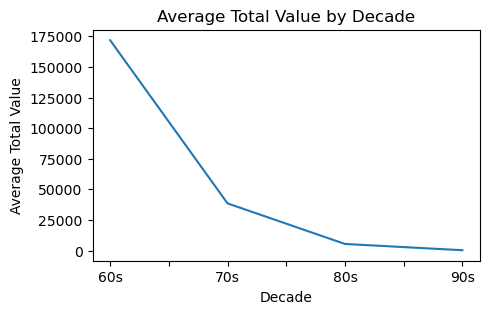

In [25]:
avg_decade = mmb_tidy.groupby("Decade")["Value"].mean()

avg_decade.plot(figsize = (5, 3))

plt.title("Average Total Value by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Total Value")
plt.show()

## Visualization 2: Average total value graph by decade and source

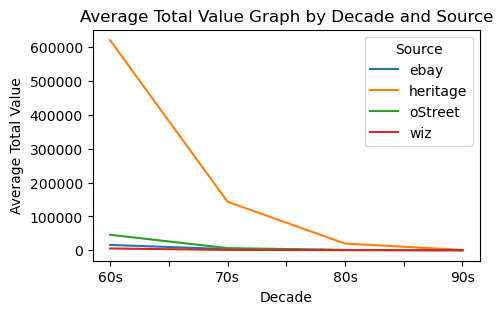

In [27]:
avg_decade_source.T.plot(figsize = (5, 3))

plt.title("Average Total Value Graph by Decade and Source")
plt.xlabel("Decade")
plt.ylabel("Average Total Value")
plt.show()

## Visualization 3: Top 10 X-Men Members ranked by total value

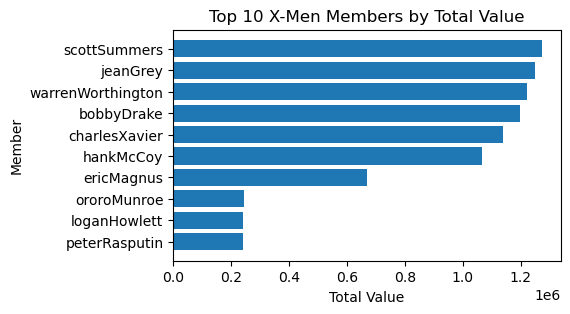

In [29]:
top_members_ranked = members_ranked.head(10).sort_values("Value")

plt.figure(figsize=(5, 3))
plt.title("Top 10 X-Men Members by Total Value")
plt.xlabel("Total Value")
plt.ylabel("Member")
plt.barh(top_members_ranked["Member"], top_members_ranked["Value"])
plt.show()